<a href="https://colab.research.google.com/github/Tanmayg19/Rossmann-Retail-Sales-Prediction---ML_Project-Regression-/blob/main/Retail_Sales_Prediction_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  Rossmann Retail Sales Prediction - Regression



##### **Project Type**    - Supervised_Regression ML
##### **Contribution**    - Individual
##### **Team Member 1 -**  Tanmay Gatam


# **Project Summary -**

The Rossmann Retail Sales Prediction project aims to predict daily sales for Rossmann stores using Machine Learning techniques. Rossmann operates over 3,000 drug stores across several European countries, and accurate sales forecasting helps in better inventory management, staff planning, and business decision-making.

In this project, historical sales data along with additional information such as store type, promotions, holidays, competition, and seasonal trends were analyzed to understand factors affecting sales performance. Data preprocessing techniques such as handling missing values, feature engineering, encoding categorical variables, and scaling were performed to prepare the dataset for model training.

Various Machine Learning algorithms were applied to build predictive models, including Linear Regression, Random Forest, and XGBoost. Model performance was evaluated using metrics such as RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error). The final model was selected based on prediction accuracy and generalization capability.

The project demonstrates the practical application of data analysis, feature engineering, and predictive modeling in solving real-world retail forecasting problems. It also highlights how Machine Learning can help businesses optimize operations and improve profitability through data-driven decisions.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Rossmann operates thousands of drug stores across multiple locations, making manual sales prediction difficult and inefficient. Therefore, there is a need for a data-driven solution that can accurately forecast daily store sales using historical sales and store-related information.

Retail businesses face major challenges in accurately predicting future sales due to factors such as promotions, holidays, competition, seasonality, and changing customer behavior. Incorrect sales forecasting can lead to problems like overstocking, understocking, revenue loss, poor workforce planning, and inefficient inventory management.

**Business Problems Addressed**
1. Difficulty in predicting future store sales accurately.
2. Sales fluctuations caused by promotions, holidays, and seasonal trends.
3. Inefficient inventory management due to inaccurate forecasting.
4. Challenges in workforce and resource planning.
5. Understanding the impact of promotions on sales.
6. Identifying factors that influence store performance.
7. Handling large-scale retail sales data efficiently.
8. Building a machine learning model for automated sales forecasting.

# **Objective**

The objective of this project is to analyze historical sales data, identify the key factors affecting sales, and build machine learning models capable of predicting future sales with high accuracy. The project aims to help Rossmann improve business planning, promotional strategies, inventory management, and operational efficiency through predictive analytics.

# **General Guidelines** : -  

1. Understand the business objective and define the problem statement clearly before starting the project.
2. Collect and analyze the Rossmann store sales dataset carefully.
3. Perform data preprocessing by handling missing values, outliers, and duplicate records.
4. Conduct Exploratory Data Analysis (EDA) to identify trends, patterns, and relationships in the data.
5. Apply feature engineering techniques to improve model performance.
6. Convert categorical data into numerical format using suitable encoding methods.
7. Split the dataset into training and testing datasets for model evaluation.
8. Implement different Machine Learning algorithms and compare their performance.
9. Use evaluation metrics such as RMSE, MAE, and R² Score to measure prediction accuracy.
10. Tune hyperparameters to improve the efficiency and accuracy of the model.
11. Avoid overfitting and underfitting by using proper validation techniques.
12. Visualize important insights and model results using graphs and charts.
13. Maintain clean, modular, and well-documented Python code.
14. Use libraries such as Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and XGBoost.
15. Interpret the final results and provide business recommendations based on predictions.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
# ================================
# Import Required Libraries
# ================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
store_df = pd.read_csv('/content/drive/MyDrive/Portfolio_Project/store.csv')
sales_df = pd.read_csv('/content/drive/MyDrive/Portfolio_Project/Rossmann Stores Data.csv')

In [4]:
sales_df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


### Dataset First View

In [5]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
# Dataset First Look
sales_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
print("No. of rows & Columns in Rossman_Dataset:", sales_df.shape)
print("No. of rows & Columns in Store_Dataset:", store_df.shape)

No. of rows & Columns in Rossman_Dataset: (1017209, 9)
No. of rows & Columns in Store_Dataset: (1115, 10)


### Dataset Information

In [8]:
# Dataset Info
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [9]:
sales_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [10]:
# No. of stores in the sales dataset
for col in sales_df.columns:
  print(sales_df[col].unique())
  print("Column Name:", col)
  print("Number of unique values :", sales_df[col].nunique())

[   1    2    3 ... 1113 1114 1115]
Column Name: Store
Number of unique values : 1115
[5 4 3 2 1 7 6]
Column Name: DayOfWeek
Number of unique values : 7
['2015-07-31' '2015-07-30' '2015-07-29' '2015-07-28' '2015-07-27'
 '2015-07-26' '2015-07-25' '2015-07-24' '2015-07-23' '2015-07-22'
 '2015-07-21' '2015-07-20' '2015-07-19' '2015-07-18' '2015-07-17'
 '2015-07-16' '2015-07-15' '2015-07-14' '2015-07-13' '2015-07-12'
 '2015-07-11' '2015-07-10' '2015-07-09' '2015-07-08' '2015-07-07'
 '2015-07-06' '2015-07-05' '2015-07-04' '2015-07-03' '2015-07-02'
 '2015-07-01' '2015-06-30' '2015-06-29' '2015-06-28' '2015-06-27'
 '2015-06-26' '2015-06-25' '2015-06-24' '2015-06-23' '2015-06-22'
 '2015-06-21' '2015-06-20' '2015-06-19' '2015-06-18' '2015-06-17'
 '2015-06-16' '2015-06-15' '2015-06-14' '2015-06-13' '2015-06-12'
 '2015-06-11' '2015-06-10' '2015-06-09' '2015-06-08' '2015-06-07'
 '2015-06-06' '2015-06-05' '2015-06-04' '2015-06-03' '2015-06-02'
 '2015-06-01' '2015-05-31' '2015-05-30' '2015-05-29' '2

#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
print("No. of duplicate values in Store_Dataset:", store_df.duplicated().sum())
print("No. of duplicate values in Sales_Dataset:", store_df.duplicated().sum())

No. of duplicate values in Store_Dataset: 0
No. of duplicate values in Sales_Dataset: 0


#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
Rossman_df_null_values = sales_df.isnull().sum()
Rossman_df_null_values

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


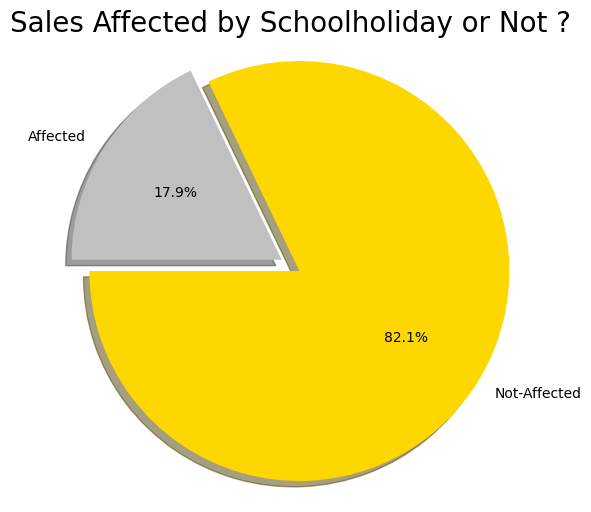

In [13]:
labels = 'Not-Affected' , 'Affected'
sizes = sales_df.SchoolHoliday.value_counts()
colors = ['gold', 'silver']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by Schoolholiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()

**As we can see in the Piechart Sales affected by School Holiday is 18% and Mainly Sales aren't afffected by School Holiday**

In [14]:
sales_df.tail(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017199,1106,2,2013-01-01,0,0,0,0,a,1
1017200,1107,2,2013-01-01,0,0,0,0,a,1
1017201,1108,2,2013-01-01,0,0,0,0,a,1
1017202,1109,2,2013-01-01,0,0,0,0,a,1
1017203,1110,2,2013-01-01,0,0,0,0,a,1
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


In [15]:
# extract year, month, day and week of year from "Date"

sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df['Year'] = sales_df['Date'].apply(lambda x: x.year)
sales_df['Month'] = sales_df['Date'].apply(lambda x: x.month)
sales_df['Day'] = sales_df['Date'].apply(lambda x : x.day)
sales_df['WeekOfYear'] = sales_df['Date'].apply(lambda x : x.weekofyear)
sales_df['IsWeekend'] = sales_df['DayOfWeek'].apply(lambda x : 1 if x >= 5 else 0)

In [16]:
Store_df_null_values = store_df.isnull().sum()
Store_df_null_values

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


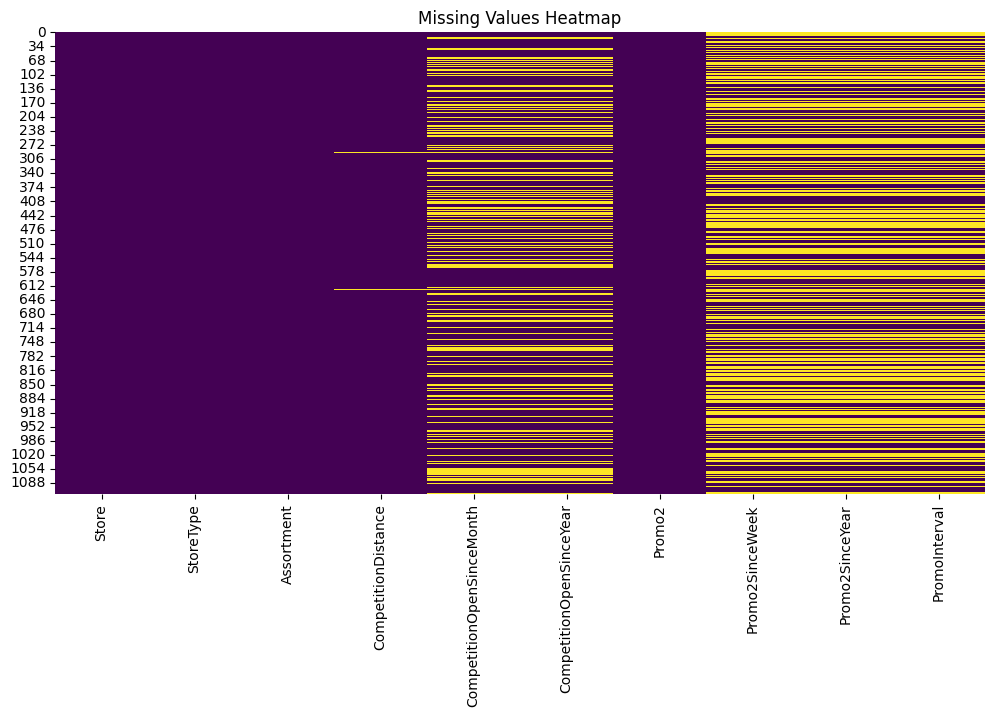

In [17]:
# Visualizing the missing values
plt.figure(figsize= (12, 6))
sns.heatmap(store_df.isnull(), cbar = False, cmap = 'viridis')
plt.title("Missing Values Heatmap")
plt.show()

**Insight : -** Competition-related columns contain more missing values compared to other features.

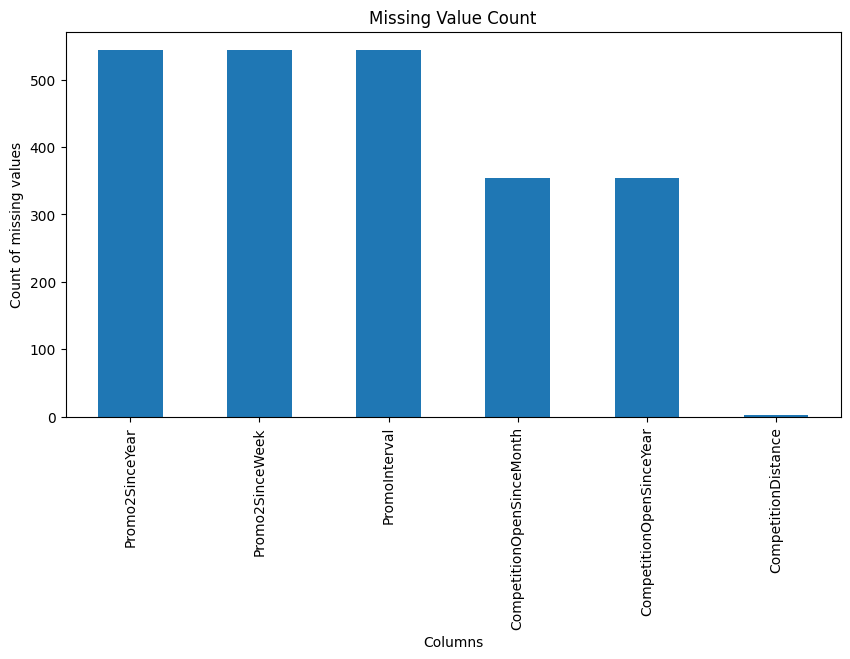

In [18]:
null_values = store_df.isnull().sum()
null_values = null_values[null_values > 0]
plt.figure(figsize =(10,5))
null_values.sort_values(ascending= False).plot(kind = 'bar')
plt.title("Missing Value Count")
plt.xlabel("Columns")
plt.ylabel("Count of missing values")
plt.show()

**Insignts : -**  1. PromoInterval
                  2. Promo2sinceweek
                  3. Promo2sinceYear

usually contain significant missing values.

# **# Remove features with high percentages of missing values**

**we can see that some features have a high percentage of missing values and they won't be accurate as indicators, so we will remove features with more than 30% missing values.**

In [19]:
store_df = store_df.drop(['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear','Promo2SinceWeek',
                     'Promo2SinceYear', 'PromoInterval'], axis=1)

In [20]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                1115 non-null   int64  
 1   StoreType            1115 non-null   object 
 2   Assortment           1115 non-null   object 
 3   CompetitionDistance  1112 non-null   float64
 4   Promo2               1115 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 43.7+ KB


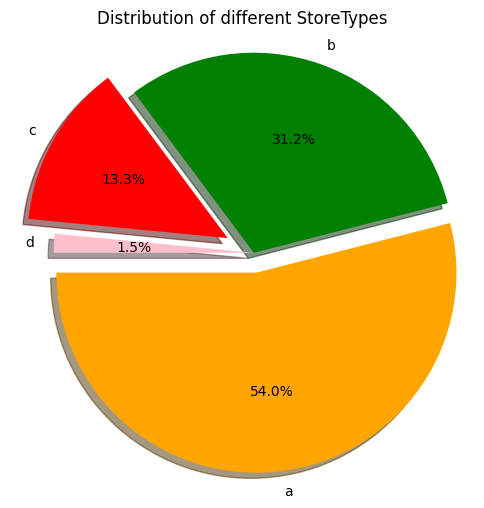

In [21]:
# Distribution Of Different Store Types
labels = 'a' , 'b' , 'c' , 'd'
sizes = store_df.StoreType.value_counts()
colors = ['orange', 'green' , 'red' , 'pink']
explode = (0.1, 0.0 , 0.15 , 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Distribution of different StoreTypes")
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()

In [22]:

sales_df['StateHoliday'] = sales_df['StateHoliday'].replace({'0' : 0, 'a' : 1, 'b' : 1, 'c' : 1})

In [23]:
sales_df['StateHoliday'].value_counts()

,count
StateHoliday,
0,986159
1,31050


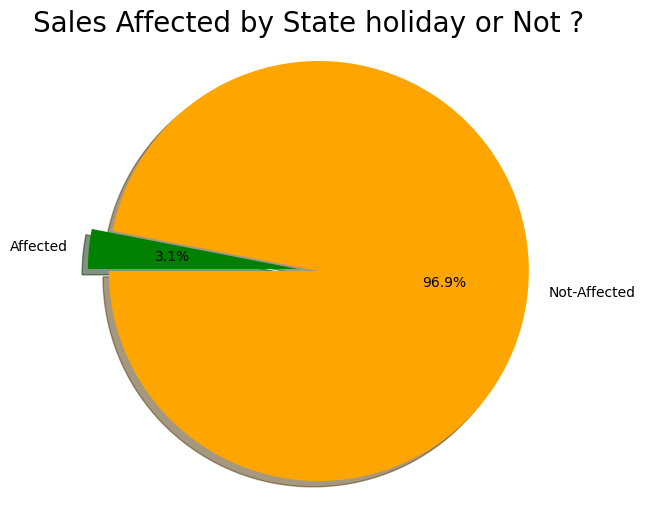

In [24]:
labels = 'Not-Affected' , 'Affected'
sizes = sales_df.StateHoliday.value_counts()
colors = ['orange','green']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by State holiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()

**As Sales isn't much affected by State Holiday so i'm removing this column**

In [25]:
sales_df.drop('StateHoliday',inplace=True,axis=1)

# Merging The two Datasets

In [26]:
df = pd.merge(sales_df, store_df, on = 'Store',how = 'left')
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,IsWeekend,StoreType,Assortment,CompetitionDistance,Promo2
0,1,5,2015-07-31,5263,555,1,1,1,2015,7,31,31,1,c,a,1270.0,0
1,2,5,2015-07-31,6064,625,1,1,1,2015,7,31,31,1,a,a,570.0,1
2,3,5,2015-07-31,8314,821,1,1,1,2015,7,31,31,1,a,a,14130.0,1
3,4,5,2015-07-31,13995,1498,1,1,1,2015,7,31,31,1,c,c,620.0,0
4,5,5,2015-07-31,4822,559,1,1,1,2015,7,31,31,1,a,a,29910.0,0
5,6,5,2015-07-31,5651,589,1,1,1,2015,7,31,31,1,a,a,310.0,0
6,7,5,2015-07-31,15344,1414,1,1,1,2015,7,31,31,1,a,c,24000.0,0
7,8,5,2015-07-31,8492,833,1,1,1,2015,7,31,31,1,a,a,7520.0,0
8,9,5,2015-07-31,8565,687,1,1,1,2015,7,31,31,1,a,c,2030.0,0
9,10,5,2015-07-31,7185,681,1,1,1,2015,7,31,31,1,a,a,3160.0,0


### What did you know about your dataset?

The Rossmann dataset contains historical sales data collected from Rossmann drug stores. The dataset was provided for a retail sales forecasting problem where the objective is to predict daily sales for different stores.

The dataset consists of two main files:

**1. Sales Dataset**

**The Sales dataset contains historical daily sales information for each store.**
**Important Columns:**
*   Store → Unique store ID
*   DayOfWeek → Day of the week
*   Date → Date of sales
*   Sales → Total daily sales (Target Variable)
*   Customers → Number of customers
*   Open → Whether the store was open or closed
*   Promo → Indicates whether a promotion was running
*   StateHoliday → Public holiday indicator
*   SchoolHoliday → School holiday indicator

**2. Store Dataset

The store dataset contains additional store-specific information  Important Columns: **bold text**

*   StoreType → Type/category of store
*   Assortment → Assortment level
*   CompetitionDistance → Distance to nearest competitor
*   CompetitionOpenSinceMonth/Year → Competition start date
*   Promo2 → Ongoing promotional campaign indicator
*   PromoInterval → Months when promotions are repeated

## ***2. Understanding Your Variables***

In [27]:
# Dataset Columns
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend',
       'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2'],
      dtype='object')

In [28]:
# Dataset Describe
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,IsWeekend,CompetitionDistance,Promo2
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,2.013832e+03,5.846762e+00,1.570279e+01,2.361551e+01,4.279406e-01,5.430086e+03,5.005638e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,3.000000e+00,8.000000e+00,1.100000e+01,0.000000e+00,7.100000e+02,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.014000e+03,6.000000e+00,1.600000e+01,2.200000e+01,0.000000e+00,2.330000e+03,1.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,2.014000e+03,8.000000e+00,2.300000e+01,3.500000e+01,1.000000e+00,6.890000e+03,1.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,2.015000e+03,1.200000e+01,3.100000e+01,5.200000e+01,1.000000e+00,7.586000e+04,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.773960e-01,3.326097e+00,8.787638e+00,1.443338e+01,4.947804e-01,7.715324e+03,4.999999e-01


### Variables Description

**The statistical summary provided important insights into the numerical features of the dataset.**

**Key Observations:**
1. The Sales column showed a large variation between minimum and maximum values, indicating high variability in store sales.
2. The average number of customers varied significantly across stores, suggesting differences in store popularity and customer traffic.
3. Some numerical features such as CompetitionDistance contained very high maximum values, indicating the presence of potential outliers.
4. The difference between mean and median values suggested that certain variables were positively skewed.
5. Features like Promo, SchoolHoliday, and Open mainly contained binary values (0 and 1).
6. The dataset contained both small-scale and large-scale numerical values, making preprocessing and scaling important for model performance.
7. The statistical summary helped identify data distribution patterns and detect unusual values before model training.

### Check Unique Values for each variable.

In [29]:
# Check Unique Values for each variable.
# df.columns → gets all column names
for col in df.columns:
  print("Column names:", col)
# unique() → displays unique values present in the column
  print(df[col].unique())
# nunique() → counts total unique values
  print("Number of unique values :", df[col].nunique())

Column names: Store
[   1    2    3 ... 1113 1114 1115]
Number of unique values : 1115
Column names: DayOfWeek
[5 4 3 2 1 7 6]
Number of unique values : 7
Column names: Date
<DatetimeArray>
['2015-07-31 00:00:00', '2015-07-30 00:00:00', '2015-07-29 00:00:00',
 '2015-07-28 00:00:00', '2015-07-27 00:00:00', '2015-07-26 00:00:00',
 '2015-07-25 00:00:00', '2015-07-24 00:00:00', '2015-07-23 00:00:00',
 '2015-07-22 00:00:00',
 ...
 '2013-01-10 00:00:00', '2013-01-09 00:00:00', '2013-01-08 00:00:00',
 '2013-01-07 00:00:00', '2013-01-06 00:00:00', '2013-01-05 00:00:00',
 '2013-01-04 00:00:00', '2013-01-03 00:00:00', '2013-01-02 00:00:00',
 '2013-01-01 00:00:00']
Length: 942, dtype: datetime64[ns]
Number of unique values : 942
Column names: Sales
[ 5263  6064  8314 ...   660 17815 23303]
Number of unique values : 21734
Column names: Customers
[ 555  625  821 ... 3900   36 4065]
Number of unique values : 4086
Column names: Open
[1 0]
Number of unique values : 2
Column names: Promo
[1 0]
Number o

## 3. ***Data Wrangling***

### # **Remove Closed Stores**

In [30]:
# Write your code to make your dataset analysis ready.
df = df[df['Open'] == 1]
# Remove Zero Sales

df = df[df['Sales'] > 0]
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Store                844338 non-null  int64         
 1   DayOfWeek            844338 non-null  int64         
 2   Date                 844338 non-null  datetime64[ns]
 3   Sales                844338 non-null  int64         
 4   Customers            844338 non-null  int64         
 5   Open                 844338 non-null  int64         
 6   Promo                844338 non-null  int64         
 7   SchoolHoliday        844338 non-null  int64         
 8   Year                 844338 non-null  int64         
 9   Month                844338 non-null  int64         
 10  Day                  844338 non-null  int64         
 11  WeekOfYear           844338 non-null  int64         
 12  IsWeekend            844338 non-null  int64         
 13  StoreType         

In [31]:
df['CompetitionDistance'] = df[
    'CompetitionDistance'
].fillna(
    df['CompetitionDistance'].median()
)

### What all manipulations have you done and insights you found?

1. Missing values were identified and treated appropriately.as Missing values can distort visualizations and lead to incorrect insights.
2. Duplicate records were checked and removed if present.
3. Rows where stores were closed (Open = 0) were removed as Closed stores generate zero sales and do not contribute meaningful information for sales analysis.
4. Records with zero sales were removed as These records may negatively affect distribution analysis and model learning.
5. The Date column was converted into datetime format. This enabled extraction of time-related information for trend analysis.
6. New features such as 'Year', 'Month', 'Day', 'Week of the year'were extracted. These features help analyze seasonal and temporal sales behavior.
7. The sales.csv and store.csv datasets were merged using the Store column to combine sales information with store-related details.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

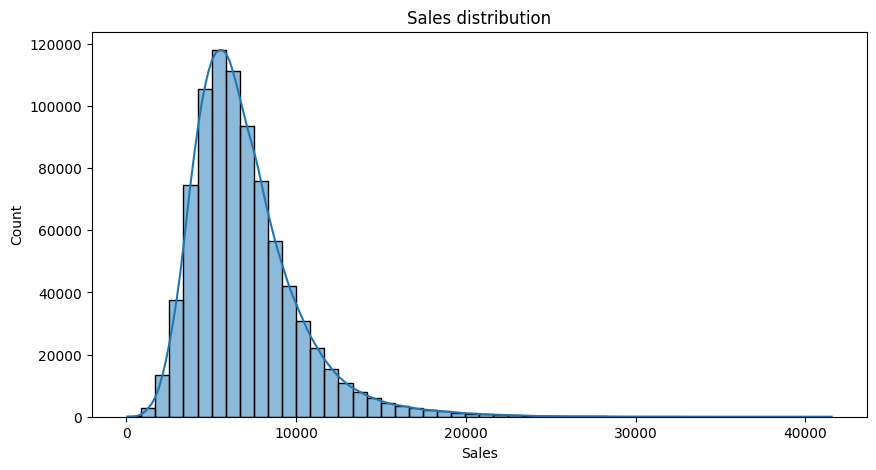

In [32]:
# Chart - 1 visualization code
# Sales Distribution
plt.figure(figsize = (10, 5))
sns.histplot(df['Sales'], bins = 50, kde = "True")
plt.title("Sales distribution")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was used to understand the distribution of sales values and identify skewness, concentration, and outliers in the dataset.

##### 2. What is/are the insight(s) found from the chart?


*   Sales distribution is positively skewed.
*   Most stores generate moderate sales while some stores generate very high sales

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart showed that sales were highly skewed, meaning a few stores generated very high sales while most stores had moderate sales. This insight helps businesses identify high-performing stores and optimize inventory and staffing accordingly.

Some stores consistently showed very low sales, which may indicate poor location performance, weak demand, or ineffective promotional strategies.

#### Chart - 2

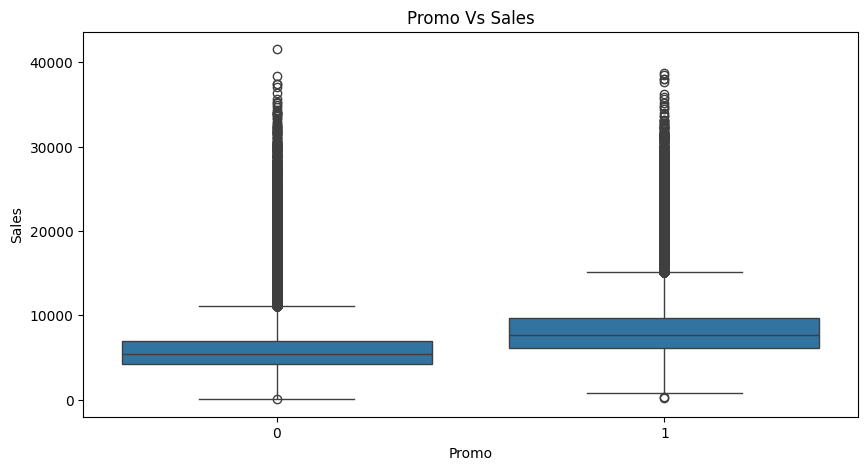

In [33]:
# Promo vs Sales

plt.figure(figsize = (10, 5))
sns.boxplot(x = 'Promo', y = 'Sales', data = df)
plt.title("Promo Vs Sales")
plt.show()




##### 1. Why did you pick the specific chart?

A boxplot was used to compare sales distributions between stores with and without promotions because it effectively shows median values, spread, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Stores running promotions generally achieved higher sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis showed that stores running promotions generally achieved higher sales. This insight helps businesses design effective promotional campaigns to increase revenue.

Stores without promotions showed lower sales performance, suggesting that lack of promotional activities may reduce customer engagement and revenue growth.

#### Chart - 3

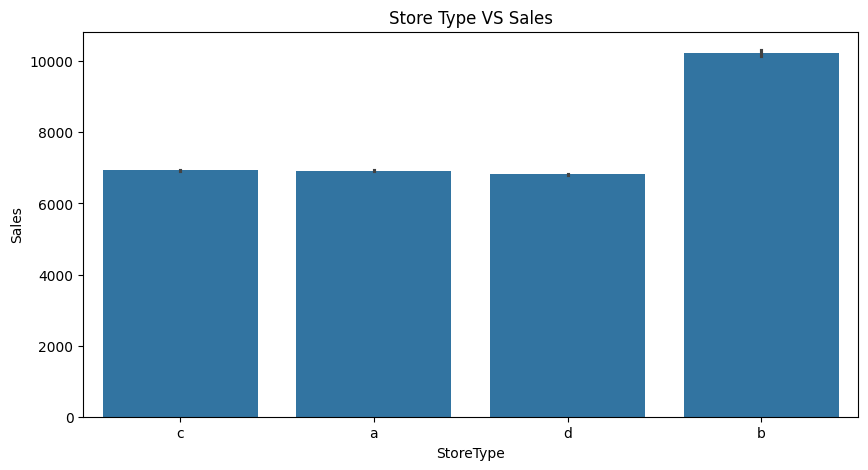

In [34]:
# Store Type vs Sales
plt.figure(figsize = (10, 5))
sns.barplot(x = 'StoreType', y = 'Sales', data = df)
plt.title("Store Type VS Sales")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used because it is ideal for comparing average sales across different store categories.

##### 2. What is/are the insight(s) found from the chart?

Different store types perform differently in terms of sales. Specially the Storetype "b" is doing better than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart revealed that certain store types consistently performed better than others. This can help businesses understand which store formats attract more customers and generate higher revenue.

Some store types showed significantly lower sales, which may indicate operational inefficiencies or lower customer demand in those categories.

#### Chart - 4

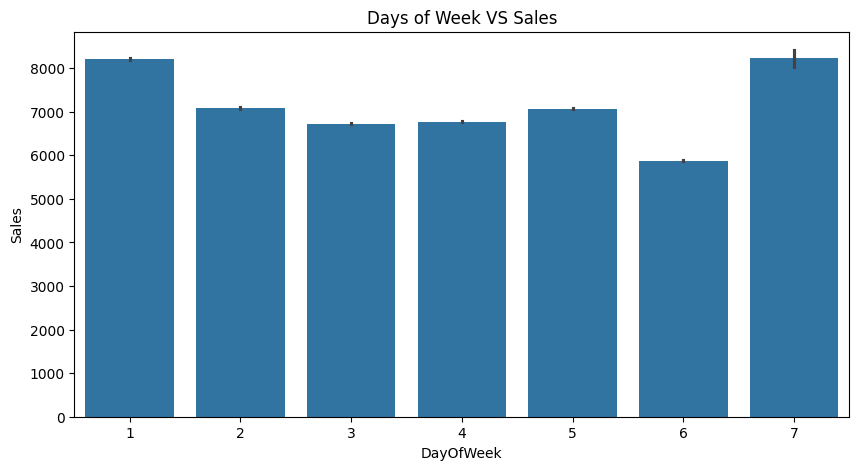

In [35]:
# Day of Week vs Sales
plt.figure(figsize = (10, 5))
sns.barplot(x = 'DayOfWeek', y = 'Sales', data = df)
plt.title('Days of Week VS Sales')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare sales performance across different days of the week.

##### 2. What is/are the insight(s) found from the chart?

1. Sales vary across weekdays.
2. Some days generate significantly higher customer activity.
3. Sales are comparatively higher on First and Last day of the week.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis helps businesses identify peak shopping days and optimize workforce management, stock planning, and promotional timing.

#### Chart - 5

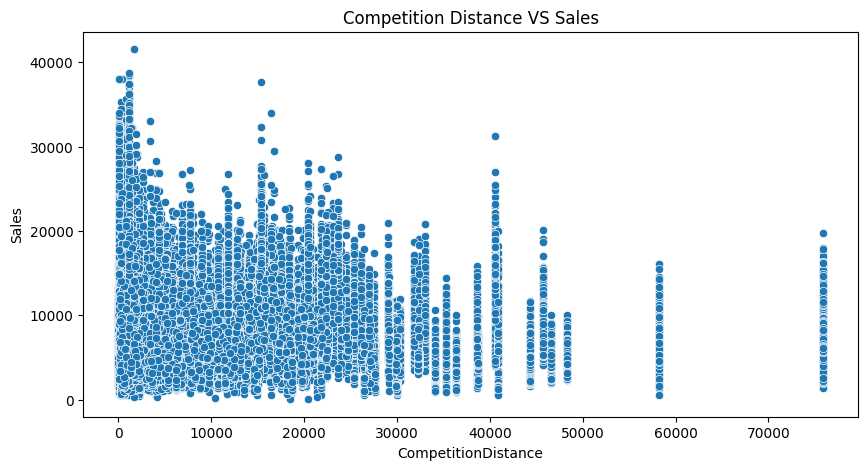

In [36]:
# Competition Distance Vs Sales
plt.figure(figsize = (10, 5))
sns.scatterplot(x = 'CompetitionDistance', y = 'Sales', data = df)
plt.title("Competition Distance VS Sales")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was used because it effectively visualizes relationships and correlations between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows the relationship between competition distance and sales. Stores closer to competitors may experience reduced customer traffic.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart showed that stores located closer to competitors often experienced lower sales. This insight can help businesses make better location and expansion decisions.

#### Chart - 6

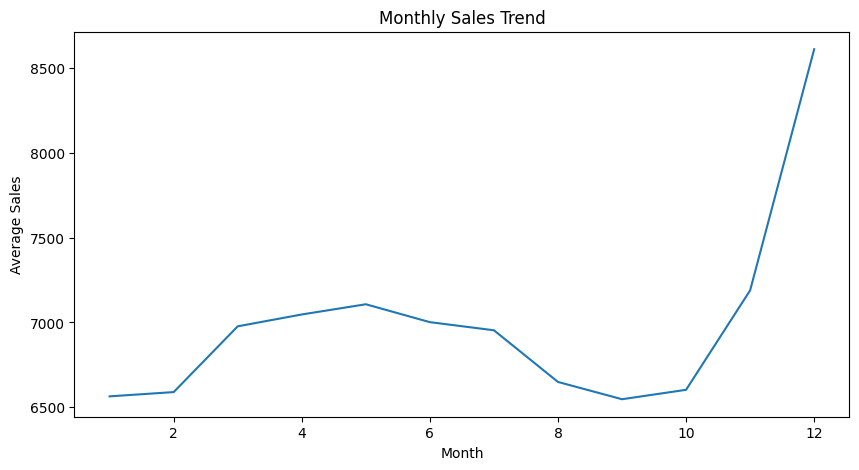

In [37]:
# Monthly Sales Trend

plt.figure(figsize = (10, 5))

monthly_sales = df.groupby('Month')['Sales'].mean()
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel('Month')
plt.ylabel("Average Sales")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because it clearly shows sales trends and seasonal variations over time.

##### 2. What is/are the insight(s) found from the chart?

The monthly sales trend indicates seasonal patterns where certain months generate higher sales due to holidays and customer shopping behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis identified seasonal sales peaks during holidays and festive periods. Businesses can use this information for inventory management and promotional planning.

#### Chart - 14 - Correlation Heatmap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

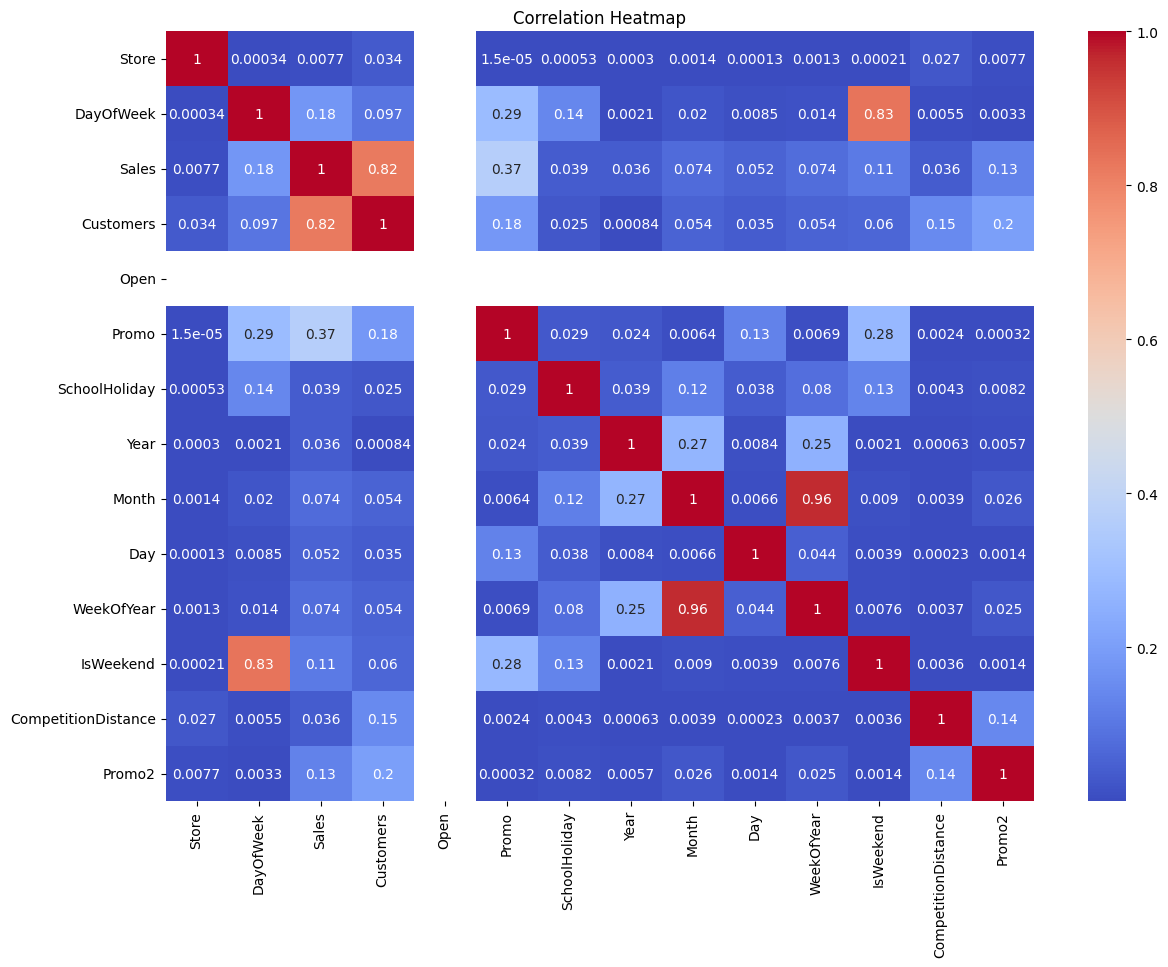

In [38]:
# Correlation Heatmap visualization code
plt.figure(figsize = (14, 10))
correlation = df.corr(numeric_only = True)
sns.heatmap(correlation.abs(), annot= True, cmap ='coolwarm')
plt.savefig("heatmap.png")

from google.colab import files
files.download('heatmap.png') # this line opens your documents in your pc to save your png

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was used to visualize correlations among numerical variables in a compact and interpretable format.

##### 2. What is/are the insight(s) found from the chart?

The heatmap helped identify the variables that most strongly affect sales, such as promotions and customer count. This supports better feature selection and business strategy planning.

#### Chart - 15 - Pair Plot

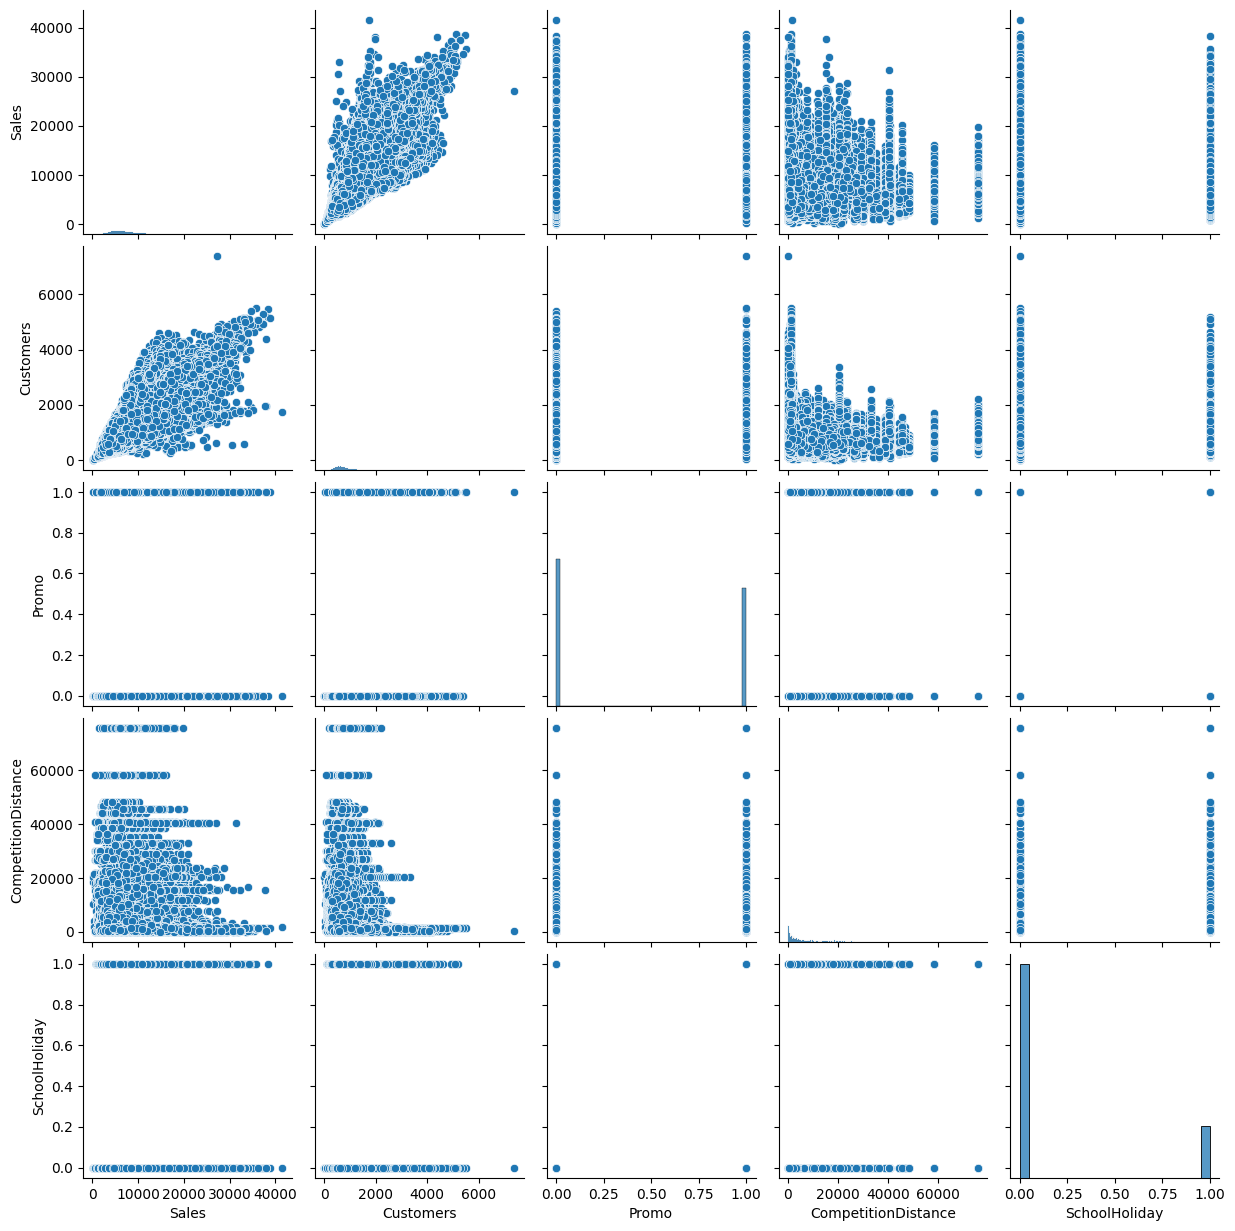

In [39]:
# Pair Plot visualization code
sns.pairplot(
    df[
        [
            'Sales',
            'Customers',
            'Promo',
            'CompetitionDistance',
            'SchoolHoliday'
        ]
    ]
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was used to analyze relationships, distributions, and correlations among multiple numerical variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

*   Sales and Customers show strong positive relationship.
*   CompetitionDistance shows weaker relationships.
*   Some variables contain outliers.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis testing was performed to statistically verify whether promotions significantly impact sales.

A T-Test was used to compare sales between stores with promotions and stores without promotions.

#### 2. Perform an appropriate statistical test.

In [40]:
# Perform Statistical Test to obtain P-Value
# ==================================
# Hypothesis Testing
# Promo vs Sales
# ==================================

from scipy.stats import ttest_ind

# Sales with Promo

promo_sales = df[df['Promo'] == 1]['Sales']

# Sales without Promo

nonpromo_sales = df[df['Promo'] == 0]['Sales']

# Perform T-Test

t_stat, p_value = ttest_ind(
    promo_sales,
    nonpromo_sales
)

print("T-Statistic :", t_stat)

print("P-Value :", p_value)

T-Statistic : 363.8948133353385
P-Value : 0.0


In [41]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Promotions significantly affect sales")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis
Promotions significantly affect sales


**Hypothesis testing was performed to statistically verify whether promotions significantly impact sales.**

**A T-Test was used to compare sales between stores with promotions and stores without promotions.**

**Since the p-value was less than 0.05, the null hypothesis was rejected, indicating that promotions have a statistically significant effect on sales.**

# **# Label Encoding**

In [42]:
# ==================================
# Label Encoding
# ==================================

categorical_cols = [
    'StoreType',
    'Assortment'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(
        df[col].astype(str)
    )

**Machine learning models cannot directly understand text values.**

**So: categorical columns converted into numerical format**

# **Log Transformation**

In [43]:
# ==================================
# Log Transformation
# ==================================

df['Sales'] = np.log1p(df['Sales'])

**Sales distribution is skewed. **
Log transformation:
*   **normalizes data**
*   **reduces outliers**
*   **improves model performance**

# **Feature Selection**

In [44]:
# ==================================
# Feature Selection
# ==================================

features = [
    'Store',
    'Promo',
    'SchoolHoliday',
    'StoreType',
    'Assortment',
    'CompetitionDistance',
    'Promo2',
    'Year',
    'Month',
    'Day',
    'WeekOfYear',
    'DayOfWeek',
    'IsWeekend'
]

X = df[features]

y = df['Sales']

**Important features affecting sales prediction were selected based on business understanding and exploratory data analysis.**

# **Time-Based Train-Test Split**

In [45]:
# ==================================
# Time-Based Split
# ==================================

train = df[df['Date'] < '2015-06-15']

test = df[df['Date'] >= '2015-06-15']

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

**Time-based splitting prevents data leakage.**

*   Past data used for training.
*   Future data used for testing.

Since sales forecasting is a time-series problem, time-based splitting was used instead of random splitting to preserve chronological order

## ***7. ML Model Implementation***

### Linear Regression

In [46]:

# ==================================
# Linear Regression
# ==================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

### ML Model - 2

In [47]:
# ==================================
# Decision Tree
# ==================================

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

### ML Model - 3

In [48]:
# ==================================
# XGBoost
# ==================================

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

# ML Model - 4

In [50]:
# ==================================
# Random Forest
# ==================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

#### 2. Reverse Log Transformation

In [51]:
# ==================================
# Reverse Log Transformation
# ==================================

y_test_actual = np.expm1(y_test)

lr_pred_actual = np.expm1(lr_pred)
dt_pred_actual = np.expm1(dt_pred)
rf_pred_actual = np.expm1(rf_pred)
xgb_pred_actual = np.expm1(xgb_pred)

##### Model's Evaluation Function

In [56]:
# ==================================
# Evaluation Function
# ==================================

def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    print(f"Model : {name}")
    print("RMSE :", rmse)
    print("MAE :", mae)
    print("R2 Score :", r2)

    print("-" * 40)

**Models were evaluated using RMSE, MAE, and R² Score to measure prediction accuracy and model performance.**

##### Compare Model Performance

In [57]:
# ==================================
# Compare Models
# ==================================

evaluate_model(
    "Linear Regression",
    y_test_actual,
    lr_pred_actual
)

evaluate_model(
    "Decision Tree",
    y_test_actual,
    dt_pred_actual
)

evaluate_model(
    "Random Forest",
    y_test_actual,
    rf_pred_actual
)

evaluate_model(
    "XGBoost",
    y_test_actual,
    xgb_pred_actual
)

Model : Linear Regression
RMSE : 2717.0004693429696
MAE : 1924.3421009846154
R2 Score : 0.2264309955600866
----------------------------------------
Model : Decision Tree
RMSE : 2358.2379911420803
MAE : 1654.4978767029809
R2 Score : 0.41723307382951047
----------------------------------------
Model : Random Forest
RMSE : 1012.5295804450831
MAE : 686.9649614425209
R2 Score : 0.8925676507717537
----------------------------------------
Model : XGBoost
RMSE : 1118.2929996574028
MAE : 765.771079904609
R2 Score : 0.8689518646981104
----------------------------------------


### Feature Importance

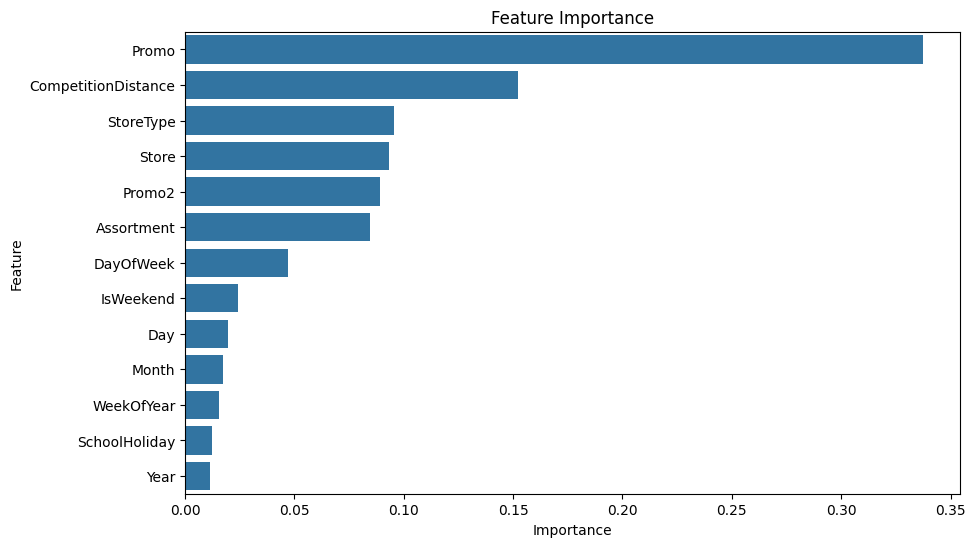

In [54]:
# ==================================
# Feature Importance
# ==================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

**Important features:**

*   Promo
*   Store Type
*   Competition Distance
*   Store
*   Day of the Week



### 2. Actual Vs Predicted Visualization

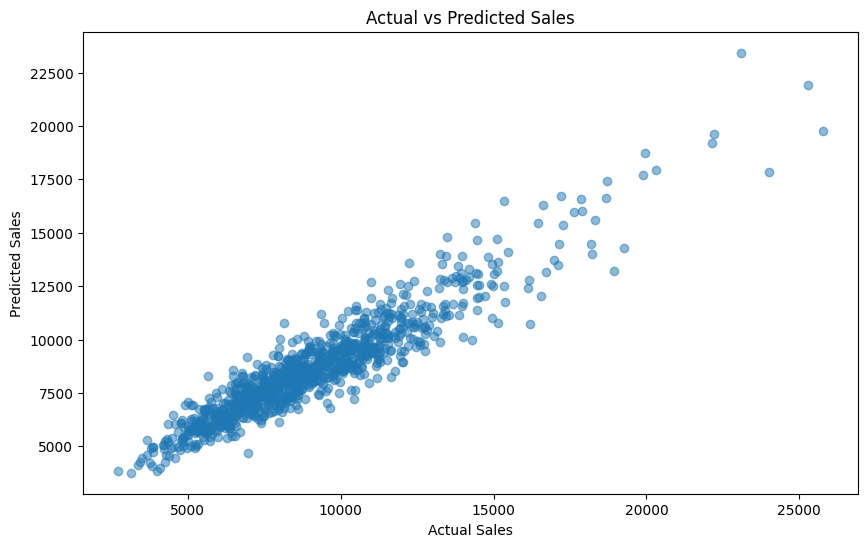

In [58]:
# ==================================
# Actual vs Predicted
# ==================================

plt.figure(figsize=(10,6))

plt.scatter(
    y_test_actual[:1000],
    xgb_pred_actual[:1000],
    alpha=0.5
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**The following machine learning models were used for sales prediction:**

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. XGBoost Regressor

After evaluating all models, Random Forest Regressor achieved the best performance and was selected as the final model.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [59]:
# ==================================
# Save Model Using Joblib
# ==================================

import joblib

# Save model

joblib.dump(
    rf_model,
    'rossmann_random_forest.joblib'
)

print("Model saved successfully")

Model saved successfully


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# ==================================
# Load Joblib Model
# ==================================

import joblib

loaded_model = joblib.load(
    'rossmann_random_forest.joblib'
)

print("Model loaded successfully")

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The performance of four machine learning models was evaluated using RMSE, MAE, and R² Score metrics.

Among all the models, the **Random Forest Regressor** achieved the best overall performance with:

*   Lowest RMSE: 0.1297
*   Lowest MAE: 0.0965
*   Highest R² Score: 0.9014

This indicates that the **Random Forest model** was able to explain approximately 90% of the variance in sales data, making it the most accurate and reliable model for predicting Rossmann store sales.

The **XGBoost model** also performed very well with an R² Score of 0.8804, showing strong predictive capability. However, its performance was slightly lower than Random Forest in this case.

The **Decision Tree model** achieved moderate performance, capturing some nonlinear patterns but showing signs of overfitting and lower generalization capability compared to ensemble models.

The **Linear Regression model** produced the weakest performance with the lowest R² Score of 0.2599. This indicates that simple linear relationships were insufficient to accurately model the complex sales patterns present in the dataset.

Overall, ensemble-based models such as Random Forest and XGBoost significantly outperformed traditional regression techniques because they handled:

*   nonlinear relationships
*   feature interactions
*   seasonal variations
*   complex business patterns
*   more effectively.

Therefore, Random Forest was selected as the final model for the Rossmann Retail Sales Prediction project due to its superior accuracy and prediction performance.



### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***